### Analysis for Crochet Bench GitHub (Peiyu Georga Li)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
from pathlib import Path


Fiona:
- 1 - 2 paragraph summary statistics (number of rows, number of categories to show that we have enough diversity in the data set to handle ad hoc querying, show that we have images, number of patterns per skill level, talk about how we can merge everything to create a long description )

Ying:
- figures and the second figure
- webscraping 

In [3]:
data_folder = Path("data/crochet_pattern_by_project")

dfs = []

for file in data_folder.glob("*.json"):
    with open(file, "r") as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df["file_name"] = file.name
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,pattern_name,materials,skill_type,skill_level,abbreviations,measurements,gauge,instructions,id,project_type,source,image_link,file_name,notes,finishing,remaining_panels,additional_instructions
0,Cross-hatched Cowl & Beanie,[RED HEART® Reflective™: 3 balls of 8884 Peaco...,crochet,easy,"[A, B = color A, B, ch = chain, hdc = half dou...",Cowl measures 5” (12.5 cm) wide x 60” (152.5 c...,COWL GAUGE: 10 sts and 9 rows = 4” (10 cm) in ...,"COWL\nWith A, Ch 150, and without twisting ch;...",RHC0116-019549M,Hats,./input_file/Hats/RHC0116-019549M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN
1,Crochet Letter Hats,"[1 skein each 1801 Navy and 1502 Iced Aqua, Su...",crochet,easy,"[ch = chain(s), hdc = half double crochet, sc ...","Hat measures 18 (20, 22)"" [45.5 (51, 56) cm] c...","12 sts = 4"" (10 cm); 9 rows = 4"" (10 cm). CHEC...",HAT (make 1 with each color)\nCh 4; join with ...,RHC0316-017277M,Hats,./input_file/Hats/RHC0316-017277M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN
2,Daisy Chain Border CardiGan & Hat,[Patons® Beehive Baby sport (100 g/3.5 oz; 328...,crochet,intermediate,"[approx = Approximate(ly)., beg = Beginning., ...","To fit chest measurement 6 mos 17” [43 cm], 12...",5½ clusters and 10 rows = 4” [10 cm] in Basic ...,The instructions are written for smallest size...,PAC0216-000028M,Hats,./input_file/Hats/PAC0216-000028M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN
3,Classic Crochet Beret,"[Bernat® Satin (100 g/3.5 oz; 182 m/200 yds), ...",crochet,intermediate,"[Ch = Chain., Cont = Continue(ity)., Inc = inc...",One size to fit average lady’s head.,15 sc and 16 rows = 4” [10 cm].,Ch 6. Join with sl st to first ch to form a ri...,BRC0116-000013M,Hats,./input_file/Hats/BRC0116-000013M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN
4,Buttoned Cloche Hat,"[RED HEART® Medley™: 2 balls 954 Eclectic, Sus...",crochet,easy,"[ch = chain(s), hdc = half double crochet, st(...",Hat measures 24” (61 cm) circumference at brim.,11 hdc = 4” (10 cm).,HAT\nCh 5; join with slip st in first ch to fo...,RHC0116-018071M,Hats,./input_file/Hats/RHC0116-018071M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN


In [4]:
combined_df.to_csv("combined_crochet_patterns.csv", index=False)

In [5]:
print (combined_df.shape)
combined_df.groupby("file_name").count()

(6085, 17)


,pattern_name,materials,skill_type,skill_level,abbreviations,measurements,gauge,instructions,id,project_type,source,image_link,notes,finishing,remaining_panels,additional_instructions
file_name,,,,,,,,,,,,,,,,
Afghans_Blankets.json,1591,1591,1591,1591,1591,1591,1591,1591,1591,1591,1591,1562,1,1,1,0
Amigurumi+%26+Toys.json,286,286,286,286,286,286,286,286,286,286,286,282,0,0,0,0
Appliqués.json,42,42,42,42,42,42,42,42,42,42,42,41,0,0,0,0
Aprons.json,11,11,11,11,11,11,11,11,11,11,11,11,0,0,0,0
Bags+%26+Purses.json,249,249,249,249,249,249,249,249,249,249,249,248,0,0,0,0
Baskets.json,118,118,118,118,118,118,118,118,118,118,118,113,0,0,0,0
Bibs.json,7,7,7,7,7,7,7,7,7,7,7,7,0,0,0,0
Booties.json,24,24,24,24,24,24,24,24,24,24,24,24,0,0,0,0
Bunting_Bags.json,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0


In [6]:
combined_df.isna().sum()

pattern_name                  0
materials                     0
skill_type                    1
skill_level                   1
abbreviations                 1
measurements                  1
gauge                         1
instructions                  1
id                            0
project_type                  0
source                        0
image_link                   75
file_name                     0
notes                      6084
finishing                  6084
remaining_panels           6084
additional_instructions    6084
dtype: int64

In [7]:
combined_df['pattern_name'] + " - " + combined_df['skill_type']

0             Cross-hatched Cowl & Beanie - crochet
1                     Crochet Letter Hats - crochet
2       Daisy Chain Border CardiGan & Hat - crochet
3                   Classic Crochet Beret - crochet
4                     Buttoned Cloche Hat - crochet
                           ...                     
6080                    Miami Beach Skirt - crochet
6081               Too Cute Ruffled Skirt - crochet
6082             Eco Ways Caribbean Skirt - crochet
6083           RIDING WAVES CROCHET SKIRT - crochet
6084          Granny Stitch Crochet Skirt - crochet
Length: 6085, dtype: object

### Analysis for Scraped Herrschners Data

In [29]:
herrschners_df = pd.read_csv("herrschners_crochet_patterns.csv")
print (herrschners_df.shape)
herrschners_df.head()

(548, 7)


,title,image,product_link,info,description,review_count,star_rating
0,Village Yarn Blue Burst Pot Holders Free Download,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/village-yarn-blue-burs...,F01729 Pot Holders Crochet Easy,Brighten your kitchen with a splash of color! ...,0,0
1,Willow Yarns Garden Song Shawlette Free Download,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/willow-yarns-garden-so...,F01728 Shawl Knit Easy,Be ready for backyard garden parties with this...,0,0
2,Herrschners English Garden Doily Free Download,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/herrschners-english-ga...,F01727 Doily Crochet Easy,No green thumb is needed to grow a garden of t...,0,0
3,Herrschners Shamrock Glow Blanket Free Download,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/herrschners-shamrock-g...,F01726 St. Patrick's Day Blanket Crochet Easy,It’s your lucky day! This free easy crochet bl...,0,0
4,Herrschners Tilework Bottle Carriers - Set of ...,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/herrschners-tilework-b...,F01725 Fashion Accessories & Novelties Croche...,Stay hydrated on the go with these cute and co...,1,5


In [30]:
herrschners_df.loc[3, 'description']

'It’s your lucky day! This free easy crochet blanket pattern makes stitching fun and easy with self-striping yarn for fewer ends to weave in. Herrschners Worsted 8 Celebrate yarn makes color changes effortless as you crochet a field of shell stitches embellished with a hint of magical sparkle. Stitch it in the St. Patrick’s Day colorway shown, or pick any other shade from the Herrschners Worsted 8 line to make this dazzling design your own! Skill Level: Easy Size: 38 x 58" (97 x 147cm) Materials: Herrschners Worsted 8 Celebrate Sparkle • 4002 Lucky Charm—4 balls Hook: US size J-10 (6mm) crochet hook or size needed to obtain gauge Extras: Yarn needle'

#### Data Cleaning

In [31]:
# 1. Removing "Free Download" from the title
herrschners_df['title'] = herrschners_df['title'].str.replace(
    r"Free Download\s*\-?\s*", "", regex=True, flags=re.IGNORECASE
).str.strip()

# 2. Removing the F + serial number specifically from the start
herrschners_df['info'] = herrschners_df['info'].str.replace(
    r"^F\d+\s?-\s?", "", regex=True
)

herrschners_df.head()

,title,image,product_link,info,description,review_count,star_rating
0,Village Yarn Blue Burst Pot Holders,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/village-yarn-blue-burs...,F01729 Pot Holders Crochet Easy,Brighten your kitchen with a splash of color! ...,0,0
1,Willow Yarns Garden Song Shawlette,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/willow-yarns-garden-so...,F01728 Shawl Knit Easy,Be ready for backyard garden parties with this...,0,0
2,Herrschners English Garden Doily,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/herrschners-english-ga...,F01727 Doily Crochet Easy,No green thumb is needed to grow a garden of t...,0,0
3,Herrschners Shamrock Glow Blanket,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/herrschners-shamrock-g...,F01726 St. Patrick's Day Blanket Crochet Easy,It’s your lucky day! This free easy crochet bl...,0,0
4,Herrschners Tilework Bottle Carriers - Set of 2,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/herrschners-tilework-b...,F01725 Fashion Accessories & Novelties Croche...,Stay hydrated on the go with these cute and co...,1,5


In [32]:
# Check for any remaining NaN values in the DataFrame
herrschners_df.loc[herrschners_df.isna().any(axis=1), :]

,title,image,product_link,info,description,review_count,star_rating
233,Pine Forest Shawl Crochet Pattern,https://cdn11.bigcommerce.com/s-wgzqwlngdf/ste...,https://herrschners.com/pine-forest-shawl-croc...,W00566 3 - Light Shawl Crochet Intermediate,NaN,0,0


In [20]:
herrschners_df.loc[0, 'description']

'Brighten your kitchen with a splash of color! These pretty and practical pot holders pair solid and multi shades of Village Yarn Craft Cotton yarn to create a beautiful blend of color and texture that makes each petite project a work of hand-stitched art. Stitch the easy crochet pot holder pattern in the blue shades shown, or change up the colors to match your kitchen décor. The pair also makes a thoughtful housewarming gift! Skill Level: Easy Size: 9 x 9" (22.9 x 22.9cm) Materials: Village Yarn™ Craft Cotton • 5090 Seaside—2 balls • 5007 Blueberry—2 balls Hook: US size I-9 (5.5mm) crochet hook or size needed to obtain gauge Extras: Yarn needle, stitch markers'

In [40]:
# Using the description column, figure out how many distinct skill levels there are
# isolate the skill level from the description column, and create a new column for it
def extract_skill_level(description):
    if pd.isna(description) or not isinstance(description, str):
        return None
    
    # Captures everything up until a period or newline
    match = re.search(r"skill level:\s*(\S+)", description.lower())
    if match:
        return match.group(1).strip()
    return None

# Apply the function to create the new column for analysis (not for the document retrieval)
herrschners_df['skill_level'] = herrschners_df['description'].apply(extract_skill_level)

# Check the distinct skill levels and how many products fall into each
skill_level_counts = herrschners_df['skill_level'].value_counts(dropna=False)
print(f"Distinct Skill Levels Found: {len(herrschners_df['skill_level'].unique())}")

Distinct Skill Levels Found: 7


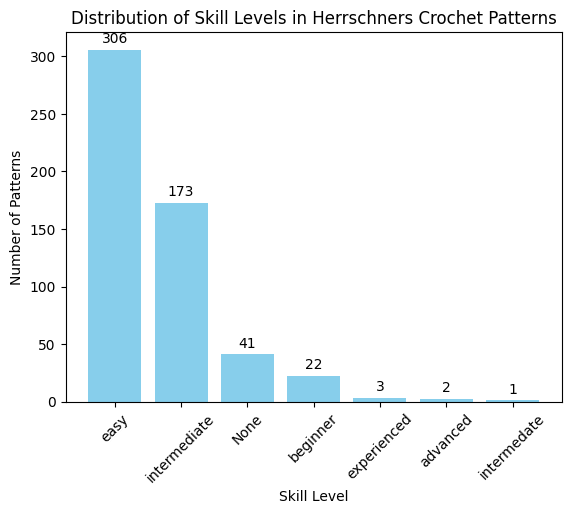

In [39]:
skill_lvls = skill_level_counts.index.astype(str)
skill_lvl_cnts = skill_level_counts.values

skill_lvl_bars = plt.bar(skill_lvls, skill_lvl_cnts, color='skyblue')
plt.bar_label(skill_lvl_bars, padding=3)
plt.xlabel('Skill Level')
plt.ylabel('Number of Patterns')
plt.title('Distribution of Skill Levels in Herrschners Crochet Patterns')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Retrieving the pattern occasion from the information column 

In [51]:
def extract_hook(description):
    if not isinstance(description, str):
        return None
    match = re.search(r"([\d\.]+)(?=\s*mm)", description.lower())
    if match:
        return match.group(1).strip()
    else:
        print (f"No hook size found in description: {description}")
        return None

herrschners_df['hook'] = herrschners_df['description'].apply(extract_hook)

No hook size found in description: Create trees of fluffy pompoms without the hassle of making pompoms using Red Heart Pomp-a-Doodle yarn.
No hook size found in description: Treat a child to warm feet with these adorable bunny slippers! These won't take long to knit and will create memorable moments for the lucky kid that receives them. Intermediate knit instructions. Requires 1 skein of Red Heart Super Saver in white plus small amounts of pink and black to make child sizes Small, Medium, or Large.
No hook size found in description: Create a quick and easy wreath inspired by Sesame Street’s Big Bird! This fun yarn project using Lion Brand Sesame Street Fuzzy Friends yarn requires no knitting or crocheting skills, so it’s a perfect project for any crafter—even kids! The yellow feathery texture of the wreath adds a pop of sunshine to your home, and the addition of printed Big Bird eyes adds a fun detail that will delight kids and kids at heart. Skill Level: Beginner Size: 14" (36cm) dia.

Distinct Hook Types Found: 18


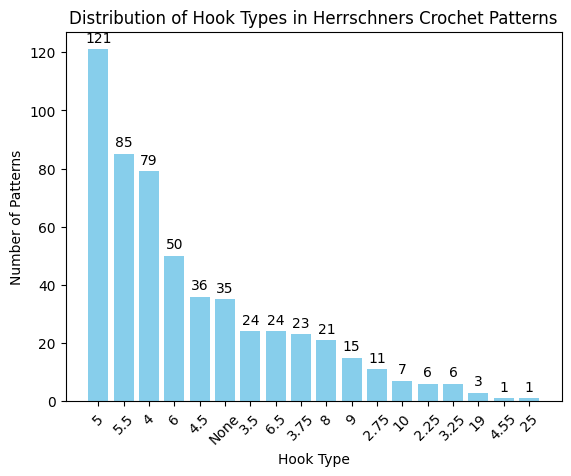

In [52]:
# couting the distinct hook types and how many patterns fall into each
hook_full_counts = herrschners_df['hook'].value_counts(dropna=False)
print(f"Distinct Hook Types Found: {len(herrschners_df['hook'].unique())}")

hook_lvls = hook_full_counts.index.astype(str)
hook_lvl_cnts = hook_full_counts.values

hook_lvl_bars = plt.bar(hook_lvls, hook_lvl_cnts, color='skyblue')
plt.bar_label(hook_lvl_bars, padding=3)
plt.xlabel('Hook Type')
plt.ylabel('Number of Patterns')
plt.title('Distribution of Hook Types in Herrschners Crochet Patterns')
plt.xticks(rotation=45)
plt.show()

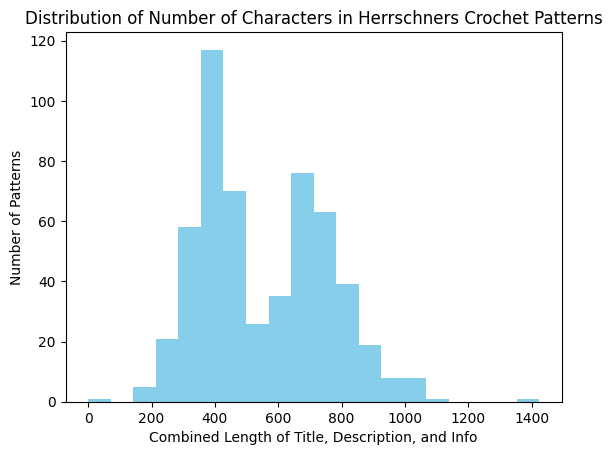

In [60]:
description_len = (herrschners_df['title'] + " " + herrschners_df['description'] + " " + herrschners_df['info']).apply(lambda x: len(x) if isinstance(x, str) else 0)
plt.hist(description_len, bins=20, color='skyblue')
plt.xlabel('Combined Length of Title, Description, and Info')
plt.ylabel('Number of Patterns')
plt.title('Distribution of Number of Characters in Herrschners Crochet Patterns')
plt.show()

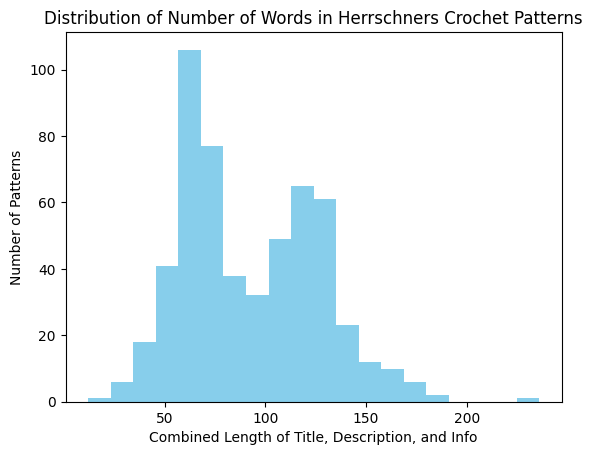

In [61]:
# for each description length, count how many words are in each description, and plot the distribution of word counts for each description length
herrschners_df["combined_description"] = (
    herrschners_df["title"].fillna("") + " " +
    herrschners_df["description"].fillna("") + herrschners_df["info"].fillna("")
)

word_counts = herrschners_df["combined_description"].apply(lambda x: len(x.split()))
plt.hist(word_counts, bins=20, color='skyblue')
plt.xlabel('Combined Length of Title, Description, and Info')
plt.ylabel('Number of Patterns')
plt.title('Distribution of Number of Words in Herrschners Crochet Patterns')
plt.show()